# What a graph is

> One launch replays a whole run; the host reads nothing until it's done.
> That is the whole reason eagle captures a graph instead of looping.

**Time:** ~2 min · **Runs on:** CPU (GPU: this notebook picks it up
automatically) · **You need:** {doc}`../quickstart_python`

You will build the figure below: a schematic of the two ways to run many
steps — reading the device after every one, or recording the sequence once
and replaying it.

## Why this matters

<!-- stale-prose-gate:
benchmarks/perf_card/card_quadro-p2000.json: d37837fb31567858848e5f1830f19431
-->

A GPU kernel launch is cheap, but a host *round trip* — launch, then read a
device value back before deciding what to launch next — is not: the host
and the device have to synchronize. A loop that reads "is anyone still
running?" after every step pays that cost every step. A CUDA **graph**
records a sequence of launches once, and the recorded graph can then repeat
itself *on the device*, with a stop condition baked in — no round trip
until the whole thing is done.

```{list-table} Reading a device value every step, vs. recording the loop once (GPU card, N = 1,000,000, spread-1000 configuration)
:header-rows: 1

* - Arm
  - What it does
  - Wall time
* - `eager_loop`
  - one launch per step, host reads the finished count after every one
  - 774 ms
* - `eagle_graph`
  - the same step, captured once into a graph with its own stop condition
  - 625 ms
```

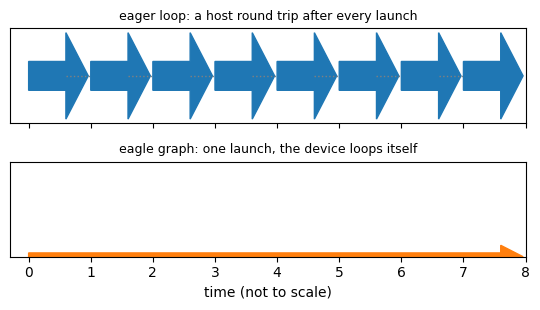

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 1, figsize=(5.5, 3.2), sharex=True)

ax = axes[0]
for i in range(8):
    ax.add_patch(mpatches.FancyArrow(i, 0, 0.6, 0, width=0.08, color="C0"))
    if i < 7:
        ax.plot([i + 0.6, i + 1], [0, 0], ":", color="gray", lw=1)
ax.set_title("eager loop: a host round trip after every launch", fontsize=9)
ax.set_yticks([])
ax.set_xlim(-0.3, 8)

ax = axes[1]
ax.add_patch(mpatches.FancyArrow(0, 0, 7.6, 0, width=0.08, color="C1"))
ax.set_title("eagle graph: one launch, the device loops itself", fontsize=9)
ax.set_yticks([])
ax.set_xlim(-0.3, 8)
ax.set_xlabel("time (not to scale)")

fig.tight_layout()
plt.show()

## The code

{func}`eagle.deploy` builds the same kernel from {doc}`../quickstart_python`
into a plan; {func}`eagle.until_done` binds it and builds the loop — on the
GPU, one {class}`~eagle.GraphPipeline` capturing the whole run; on the CPU,
the identical loop runs directly (`eagle.repeat_while`: "a host loop
everywhere else"). Either way `runner.run()` is the one call that crosses
into the device or the host team and does not return until every sample is
done (or `max_steps`).

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent.parent / "_shared"))
from nb_helpers import gpu_available, xp_for


In [3]:
DEVICE = "gpu" if gpu_available() else "cpu"
xp = xp_for(DEVICE)

In [4]:
import eagle
import hawk
from hawk import Mutable, Param, Scalar, Terminated


@hawk.kernel
def oscillator(omega: Scalar, t_end: Param, dt: Param, terminated: Terminated,
               x: Mutable[Scalar], v: Mutable[Scalar], t: Mutable[Scalar]):
    x0, v0 = x, v
    x = x0 + dt * v0
    v = v0 - dt * omega * omega * x0
    t += dt
    terminated = t >= t_end


n = 1_000_000 if DEVICE == "gpu" else 100_000
omega = xp.linspace(1.0, 3.0, n)
runner = eagle.until_done(eagle.deploy(oscillator), max_steps=10_000,
                          x=xp.ones(n), v=xp.zeros(n), t=xp.zeros(n),
                          omega=omega, t_end=1.0, dt=1e-3)
report = runner.run()
print(f"one runner.run() call -- build (capture) took {report.build_s * 1e3:.2f} ms, "
      f"the kernel fired {report.launches} times while it ran")

one runner.run() call -- build (capture) took 2.26 ms, the kernel fired 17 times while it ran


## What just happened

- `runner.run()` crossed into the device (or the host team) **once**; on
  the GPU, `build_s` is the one-time cost of recording the graph — every
  later `run()` on the same runner replays it with `build_s == 0`.
- `report.launches` counts how many times the kernel actually fired while
  the loop ran — that work happens *inside* the one captured graph (or the
  one host loop), not as separate round trips from Python.
- The same two lines (`eagle.deploy` + `eagle.until_done`) build a CUDA
  graph on the GPU and a plain loop on the CPU; nothing in the call changes.

## Try this

Call `runner.run()` a second time without `runner.reset()` first: it
returns immediately (`launches == 0`) because every sample is already
done.

## Next

- Below: the graph engine's low-level door directly — the same
  `GraphPipeline`/`Launcher` classes {func}`eagle.until_done` builds on,
  recording raw launches by hand (needs a CUDA GPU).
- {doc}`../../performance` (deeper): the eager-loop-vs-graph numbers above
  come from its card, on both a GPU and a CPU.

## The low-level door: capturing a raw launch yourself

**Needs a CUDA GPU.** {class}`~eagle.pipeline.GraphPipeline` is the Python
face of eagle's graph engine: it drives the same `eagle::cuda` C++ classes
(`Stream`, `StreamCapturer`, `Graph`, `Launcher`) every native consumer
uses. Record a sequence of launches once, then replay the instantiated
graph as many times as you like with no further Python-side dispatch.


Load the compiled kernel: `LoadedVector` wraps one already-compiled PTX
artifact (`gravity.ptx`, a two-body point-mass acceleration) with its own
sidecar metadata, with no hawk source and no recompilation.

In [5]:
import pathlib

import cupy as cp
import numpy as np

from eagle.loaded import LoadedVector
from eagle.pipeline import GraphPipeline

FIXTURES = pathlib.Path("../_fixtures").resolve()
force = LoadedVector(FIXTURES / "gravity.ptx")

Allocate the buffers the launch will read and write. Nothing inside a
captured step may allocate device memory or synchronize, so `position`,
`out` and `terminated` are all pre-allocated here, before any capture
begins.

In [6]:
MU = 3.986004418e5
N = 1024
rng = np.random.default_rng(2)
position = cp.asarray(rng.uniform(7.0e3, 4.2e4, size=(3, N)))
out = cp.zeros((3, N), dtype=cp.float64)
terminated = cp.zeros(N, dtype=cp.bool_)

Build the pipeline: `add` takes a zero-argument callable issuing exactly one
launch. Nothing inside a step may allocate device memory or synchronize —
`out`, `position` and `terminated` are all pre-allocated above. `build()`
captures the steps into a graph once and instantiates it.


In [7]:
pipe = GraphPipeline()
pipe.add(lambda: force.launch(out=out, position=position, mu=MU, terminated=terminated))
pipe.build()


`gravity`'s sidecar declares `accumulate: true`, so each replay **adds**
into `out` rather than overwriting it — replaying the graph `k` times
accumulates `k` times the single-launch answer, which is a sharp way to
check that a replay is really re-issuing the captured launch and not a
no-op.


In [8]:
replays = 5
out.fill(0.0)
pipe.launch(n=replays)
cp.cuda.runtime.deviceSynchronize()

r = cp.linalg.norm(position, axis=0)
expected_once = -MU * position / r**3
diff = cp.abs(out - replays * expected_once)
rel_err = cp.max(diff / cp.abs(replays * expected_once))
print(f"{replays} replays vs {replays}x the single-launch answer: "
      f"max rel err = {float(rel_err):.3e}")


5 replays vs 5x the single-launch answer: max rel err = 1.024e-15


See also: {doc}`../../interop` for feeding cupy/torch tensors through the
same launchers, and `eagle.compose.GraphComposer` (API reference) for
overlapping several independent pipelines on their own streams.
